<a href="https://colab.research.google.com/github/chandu-225-art/Used_Car_Price_Prediction/blob/main/Used_Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sklearn
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/used_car_price_prediction_1M.csv')
df.head()

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
3,BMW,X1,2015,21.295421,NaN,49.782079,NaN,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,2.949453e+06
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05


In [ ]:
print("Head of the dataset:")
print(df.head())
print("\nTail of the dataset:")
print(df.tail())

Head of the dataset:
      Brand   Model  Year  Mileage_kmpl    Engine_CC  Horsepower Fuel_Type  \
0    Toyota   Camry  2001     19.615852  1396.560379         NaN    Hybrid   
1   Hyundai     i20  2012     19.478608  1130.771005  137.021719    Petrol   
2  Mahindra  Bolero  2008     17.469920  1766.466250  142.902960       NaN   
3       BMW      X1  2015     21.295421          NaN   49.782079       NaN   
4     Honda   Civic  2022     18.326833  1239.334935  121.505993    Diesel   

  Transmission Owner_Type  Color     City  Kms_Driven  Insurance_Valid  \
0    Automatic      First   Grey  Chennai      500928                1   
1          NaN      First   Grey   Mumbai      211510                0   
2    Automatic      First  Black  Kolkata      333999                1   
3       Manual      First  White     Pune      225930                1   
4       Manual     Second  White  Kolkata       43404                1   

   Service_History  Accidents  Tax_Paid  Number_of_Doors  Seats  

In [ ]:
print(df.shape)

(1005000, 20)


In [ ]:
df.isnull().sum()

,0
Brand,0
Model,0
Year,0
Mileage_kmpl,80390
Engine_CC,80403
Horsepower,80403
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
df['Mileage_kmpl'].fillna(df['Mileage_kmpl'].mean(), inplace=True)
df['Engine_CC'].fillna(df['Engine_CC'].mean(), inplace=True)
df.isnull().sum()

/tmp/ipykernel_10008/3903024641.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Mileage_kmpl'].fillna(df['Mileage_kmpl'].mean(), inplace=True)
/tmp/ipykernel_10008/3903024641.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

,0
Brand,0
Model,0
Year,0
Mileage_kmpl,0
Engine_CC,0
Horsepower,80403
Fuel_Type,78733
Transmission,80385
Owner_Type,0
Color,80419


In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Categorical columns: {list(categorical_cols)}")


Categorical columns: ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City']


In [ ]:
for col in categorical_cols:
    print(f"\n--- Unique values for '{col}' ---")
    print(df[col].value_counts())



--- Unique values for 'Brand' ---
Brand
BMW             76773
Skoda           76762
Hyundai         76750
Ford            76694
Toyota          76630
Audi            76573
Honda           76542
Kia             76524
Mercedes        76492
Volkswagen      76441
Mahindra        76308
Tata            76297
Nissan          76174
 Mercedes         813
 Nissan           792
 Skoda            789
 BMW              788
 Mahindra         785
 Tata             778
 Honda            770
 Kia              769
 Hyundai          767
 Toyota           767
 Ford             745
 Volkswagen       744
 Audi             733
Name: count, dtype: int64

--- Unique values for 'Model' ---
Model
Verna        26046
Octavia      26008
Camry        25976
3 Series     25975
Amaze        25950
Figo         25942
Kushaq       25939
EcoSport     25922
A4           25919
i20          25880
E-Class      25871
Magnite      25850
Carens       25819
Virtus       25809
Q3           25807
X3           25806
Bolero       257

In [ ]:
# Remove leading/trailing spaces from 'Brand'
df['Brand'] = df['Brand'].str.strip()

print("--- Unique values for 'Brand' after cleaning ---")
print(df['Brand'].value_counts())


--- Unique values for 'Brand' after cleaning ---
Brand
BMW           77561
Skoda         77551
Hyundai       77517
Ford          77439
Toyota        77397
Honda         77312
Audi          77306
Mercedes      77305
Kia           77293
Volkswagen    77185
Mahindra      77093
Tata          77075
Nissan        76966
Name: count, dtype: int64


In [ ]:
# Convert to lowercase and strip spaces
df['Fuel_Type'] = df['Fuel_Type'].str.lower().str.strip()

# Map inconsistent spellings
fuel_type_mapping = {
    'hybridd': 'hybrid',
    'electrik': 'electric'
}
df['Fuel_Type'] = df['Fuel_Type'].replace(fuel_type_mapping)

# Capitalize first letter for all values
df['Fuel_Type'] = df['Fuel_Type'].str.capitalize()

print("--- Unique values for 'Fuel_Type' after cleaning ---")
print(df['Fuel_Type'].value_counts())


--- Unique values for 'Fuel_Type' after cleaning ---
Fuel_Type
Petrol      414245
Diesel      278819
Cng          90628
Electric     75782
Hybrid       66793
Name: count, dtype: int64


In [ ]:
print("--- Unique values for 'Brand' after confirmed cleaning ---")
print(df['Brand'].value_counts())

--- Unique values for 'Brand' after confirmed cleaning ---
Brand
BMW           77561
Skoda         77551
Hyundai       77517
Ford          77439
Toyota        77397
Honda         77312
Audi          77306
Mercedes      77305
Kia           77293
Volkswagen    77185
Mahindra      77093
Tata          77075
Nissan        76966
Name: count, dtype: int64


### Handling Remaining Missing Values

In [ ]:
# Display current missing values before imputation
print("Missing values before further imputation:")
print(df.isnull().sum())

# Impute 'Horsepower' with its mean
df['Horsepower'].fillna(df['Horsepower'].mean(), inplace=True)

# Impute categorical columns with their mode
for col in ['Fuel_Type', 'Transmission', 'Color', 'City']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Display missing values after imputation to confirm
print("\nMissing values after further imputation:")
print(df.isnull().sum())

Missing values before further imputation:
Brand               0
Model               0
Year                0
Mileage_kmpl        0
Engine_CC           0
Horsepower          0
Fuel_Type           0
Transmission        0
Owner_Type          0
Color               0
City                0
Kms_Driven          0
Insurance_Valid     0
Service_History     0
Accidents           0
Tax_Paid            0
Number_of_Doors     0
Seats               0
Registration_Age    0
Price               0
dtype: int64


/tmp/ipykernel_10008/3656253015.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Horsepower'].fillna(df['Horsepower'].mean(), inplace=True)



Missing values after further imputation:
Brand               0
Model               0
Year                0
Mileage_kmpl        0
Engine_CC           0
Horsepower          0
Fuel_Type           0
Transmission        0
Owner_Type          0
Color               0
City                0
Kms_Driven          0
Insurance_Valid     0
Service_History     0
Accidents           0
Tax_Paid            0
Number_of_Doors     0
Seats               0
Registration_Age    0
Price               0
dtype: int64


### Outlier Detection and Visualization

Numerical columns for outlier detection: ['Year', 'Mileage_kmpl', 'Engine_CC', 'Horsepower', 'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents', 'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age']


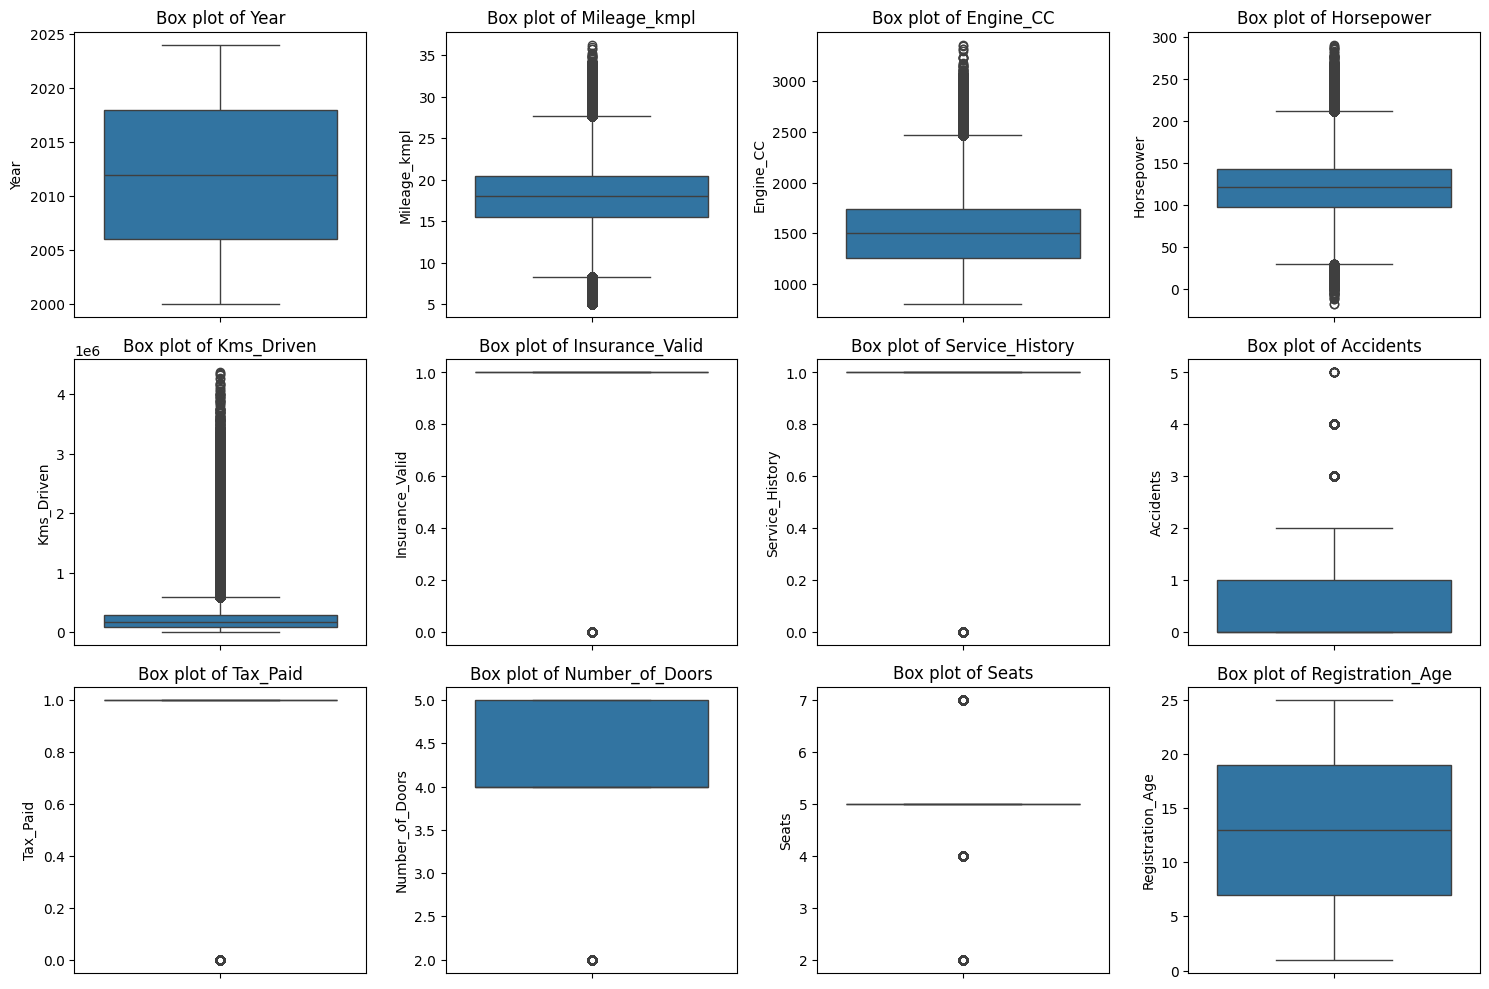

In [ ]:
# Identify numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Price') # Remove target variable from features for now

print(f"Numerical columns for outlier detection: {numerical_cols}")

# Visualize outliers in numerical features using box plots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sb.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

#### Outliers in the Target Variable ('Price')

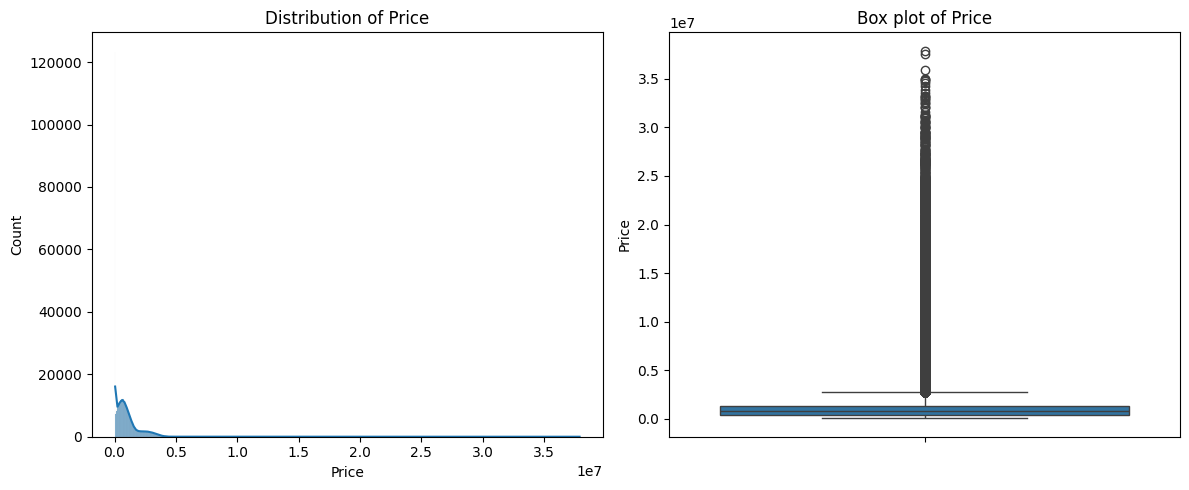

In [ ]:
# Visualize the distribution of the target variable 'Price'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sb.histplot(df['Price'], kde=True)
plt.title('Distribution of Price')

plt.subplot(1, 2, 2)
sb.boxplot(y=df['Price'])
plt.title('Box plot of Price')

plt.tight_layout()
plt.show()

### Outlier Analysis and Treatment

Applying outlier capping...
Outliers in 'Kms_Driven' capped. Upper bound: 589117.50
Outliers in 'Price' capped. Upper bound: 2718663.05


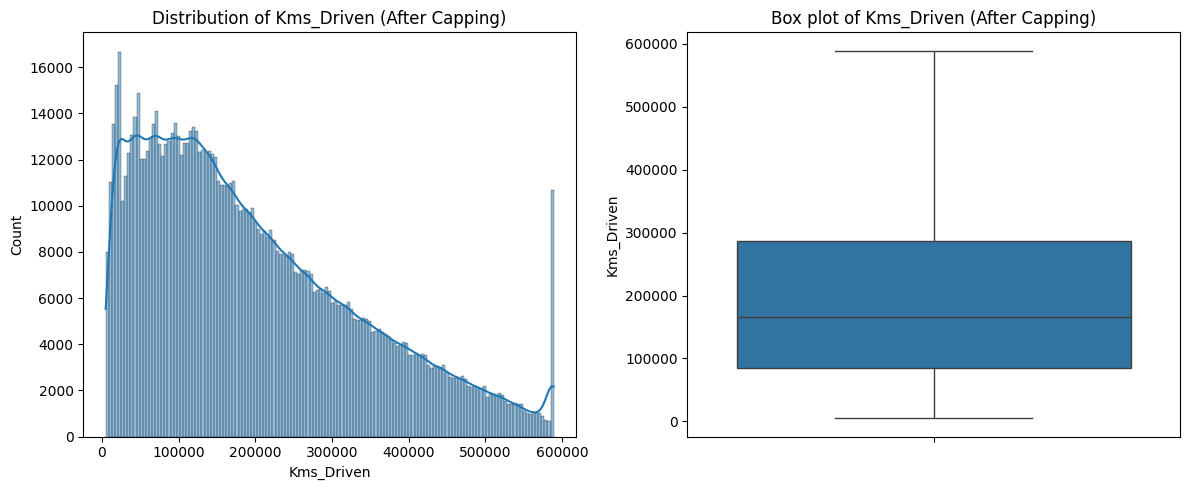

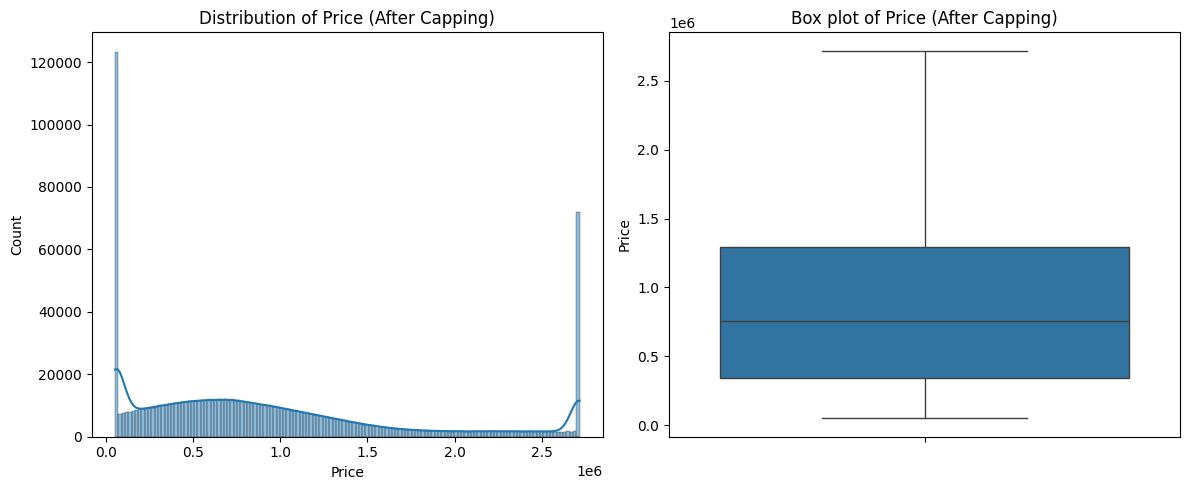

In [ ]:
# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    # Cap values above the upper bound
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    # Optionally cap values below the lower bound, though less common for right-skewed data like price/kms
    # df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    print(f"Outliers in '{column}' capped. Upper bound: {upper_bound:.2f}")

# Apply capping to 'Kms_Driven' and 'Price'
print("Applying outlier capping...")
cap_outliers_iqr(df, 'Kms_Driven')
cap_outliers_iqr(df, 'Price')

# Re-visualize 'Kms_Driven' and 'Price' to see the effect of capping
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sb.histplot(df['Kms_Driven'], kde=True)
plt.title('Distribution of Kms_Driven (After Capping)')

plt.subplot(1, 2, 2)
sb.boxplot(y=df['Kms_Driven'])
plt.title('Box plot of Kms_Driven (After Capping)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sb.histplot(df['Price'], kde=True)
plt.title('Distribution of Price (After Capping)')

plt.subplot(1, 2, 2)
sb.boxplot(y=df['Price'])
plt.title('Box plot of Price (After Capping)')

plt.tight_layout()
plt.show()

### Reviewing Remaining Categorical Columns

In [ ]:
# List of categorical columns to review
categorical_cols_to_review = ['Model', 'Owner_Type', 'Color', 'Transmission', 'City']

for col in categorical_cols_to_review:
    print(f"\n--- Unique values for '{col}' ---")
    print(df[col].value_counts())
    # Check for leading/trailing spaces as a common inconsistency
    if df[col].dtype == 'object': # Only apply strip to string columns
        if any(df[col].astype(str).str.contains(r'^\s|\s$', regex=True)):
            print(f"  Potential leading/trailing spaces detected in '{col}'.")


--- Unique values for 'Model' ---
Model
Verna        26046
Octavia      26008
Camry        25976
3 Series     25975
Amaze        25950
Figo         25942
Kushaq       25939
EcoSport     25922
A4           25919
i20          25880
E-Class      25871
Magnite      25850
Carens       25819
Virtus       25809
Q3           25807
X3           25806
Bolero       25798
Yaris        25789
Harrier      25783
X1           25780
Punch        25757
Sonet        25745
Taigun       25737
XUV700       25737
Civic        25730
Seltos       25729
GLA          25722
C-Class      25712
Polo         25639
Corolla      25632
City         25632
Slavia       25604
Sunny        25592
Creta        25591
Q5           25580
Endeavour    25575
Scorpio      25558
Nexon        25535
Kicks        25524
Name: count, dtype: int64

--- Unique values for 'Owner_Type' ---
Owner_Type
First      602365
Second     251715
Third      100653
Fourth+     50267
Name: count, dtype: int64

--- Unique values for 'Color' ---
Color
Re

## Feature Engineering

Feature engineering involves creating new features or transforming existing ones to improve the predictive power of our models. A common and highly relevant feature for car price prediction is the age of the car.

Descriptive statistics for Car_Age:
count    1.005000e+06
mean     1.200429e+01
std      7.211486e+00
min      0.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      1.800000e+01
max      2.400000e+01
Name: Car_Age, dtype: float64


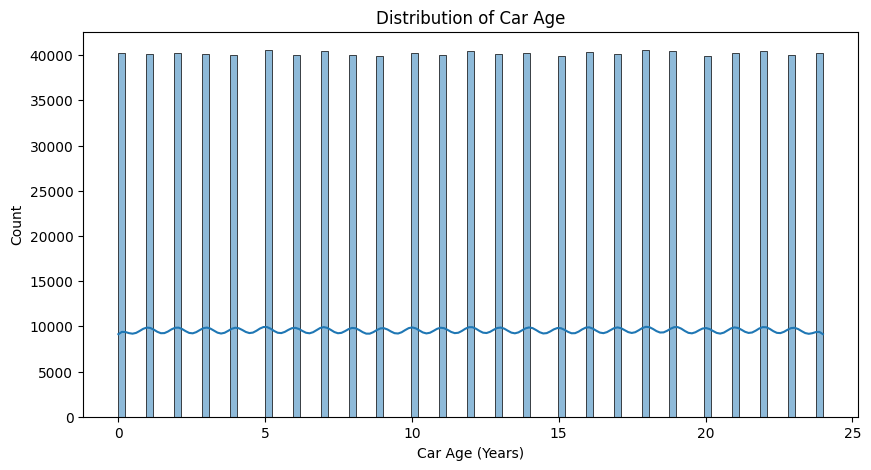

In [ ]:
# Calculate Car Age
# Assuming the current year is 2024 for age calculation
current_year = 2024
df['Car_Age'] = current_year - df['Year']

print("Descriptive statistics for Car_Age:")
print(df['Car_Age'].describe())

# Visualize the distribution of Car_Age
plt.figure(figsize=(10, 5))
sb.histplot(df['Car_Age'], kde=True)
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns to be one-hot encoded
# 'Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City'
categorical_cols_for_ohe = ['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Color', 'City']

# Initialize OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical data
ohe_features = ohe.fit_transform(df[categorical_cols_for_ohe])

# Create a DataFrame with the one-hot encoded features
ohe_df = pd.DataFrame(ohe_features, columns=ohe.get_feature_names_out(categorical_cols_for_ohe), index=df.index)

# Drop original categorical columns and concatenate with one-hot encoded DataFrame
df_encoded = pd.concat([df.drop(columns=categorical_cols_for_ohe), ohe_df], axis=1)

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame after One-Hot Encoding shape: {df_encoded.shape}")
print("First 5 rows of the encoded DataFrame:")
print(df_encoded.head())

Original DataFrame shape: (1005000, 21)
DataFrame after One-Hot Encoding shape: (1005000, 92)
First 5 rows of the encoded DataFrame:
   Year  Mileage_kmpl    Engine_CC  Horsepower  Kms_Driven  Insurance_Valid  \
0  2001     19.615852  1396.560379  120.571877    500928.0                1   
1  2012     19.478608  1130.771005  137.021719    211510.0                0   
2  2008     17.469920  1766.466250  142.902960    333999.0                1   
3  2015     21.295421  1506.627079   49.782079    225930.0                1   
4  2022     18.326833  1239.334935  121.505993     43404.0                1   

   Service_History  Accidents  Tax_Paid  Number_of_Doors  ...  Color_Silver  \
0                1          0         1                4  ...           0.0   
1                1          0         1                4  ...           0.0   
2                0          0         1                5  ...           0.0   
3                1          3         1                4  ...           0.0 

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the target variable 'Price' and 'Year', as 'Car_Age' is now preferred)
# We also exclude 'Year' itself since 'Car_Age' has been derived from it and is more relevant.
numerical_cols_for_scaling = df_encoded.select_dtypes(include=np.number).columns.tolist()
numerical_cols_for_scaling.remove('Price')
numerical_cols_for_scaling.remove('Year') # 'Car_Age' is used instead

print(f"Numerical columns for scaling: {numerical_cols_for_scaling}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified numerical columns
df_encoded[numerical_cols_for_scaling] = scaler.fit_transform(df_encoded[numerical_cols_for_scaling])

print("\nDescriptive statistics of scaled numerical features:")
print(df_encoded[numerical_cols_for_scaling].describe())
print("\nFirst 5 rows of the DataFrame after scaling numerical features:")
print(df_encoded.head())

Numerical columns for scaling: ['Mileage_kmpl', 'Engine_CC', 'Horsepower', 'Kms_Driven', 'Insurance_Valid', 'Service_History', 'Accidents', 'Tax_Paid', 'Number_of_Doors', 'Seats', 'Registration_Age', 'Car_Age', 'Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Mahindra', 'Brand_Mercedes', 'Brand_Nissan', 'Brand_Skoda', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Model_3 Series', 'Model_A4', 'Model_Amaze', 'Model_Bolero', 'Model_C-Class', 'Model_Camry', 'Model_Carens', 'Model_City', 'Model_Civic', 'Model_Corolla', 'Model_Creta', 'Model_E-Class', 'Model_EcoSport', 'Model_Endeavour', 'Model_Figo', 'Model_GLA', 'Model_Harrier', 'Model_Kicks', 'Model_Kushaq', 'Model_Magnite', 'Model_Nexon', 'Model_Octavia', 'Model_Polo', 'Model_Punch', 'Model_Q3', 'Model_Q5', 'Model_Scorpio', 'Model_Seltos', 'Model_Slavia', 'Model_Sonet', 'Model_Sunny', 'Model_Taigun', 'Model_Verna', 'Model_Virtus', 'Model_X1', 'Model_X3', 'Model_XUV700', 'Model_Yaris', 'Mod

## Feature Correlation Analysis

Top 10 features most positively correlated with Price:
Price             1.000000
Brand_Mercedes    0.448196
Brand_BMW         0.384684
Year              0.371880
Brand_Audi        0.358666
Model_E-Class     0.253255
Model_GLA         0.251213
Model_C-Class     0.251123
Model_3 Series    0.216719
Model_X1          0.216363
Name: Price, dtype: float64

Top 10 features most negatively correlated with Price:
Car_Age            -0.371880
Registration_Age   -0.371880
Kms_Driven         -0.311542
Brand_Tata         -0.163016
Brand_Ford         -0.147693
Brand_Nissan       -0.146885
Brand_Mahindra     -0.146744
Brand_Hyundai      -0.130708
Brand_Toyota       -0.115435
Brand_Honda        -0.114531
Name: Price, dtype: float64


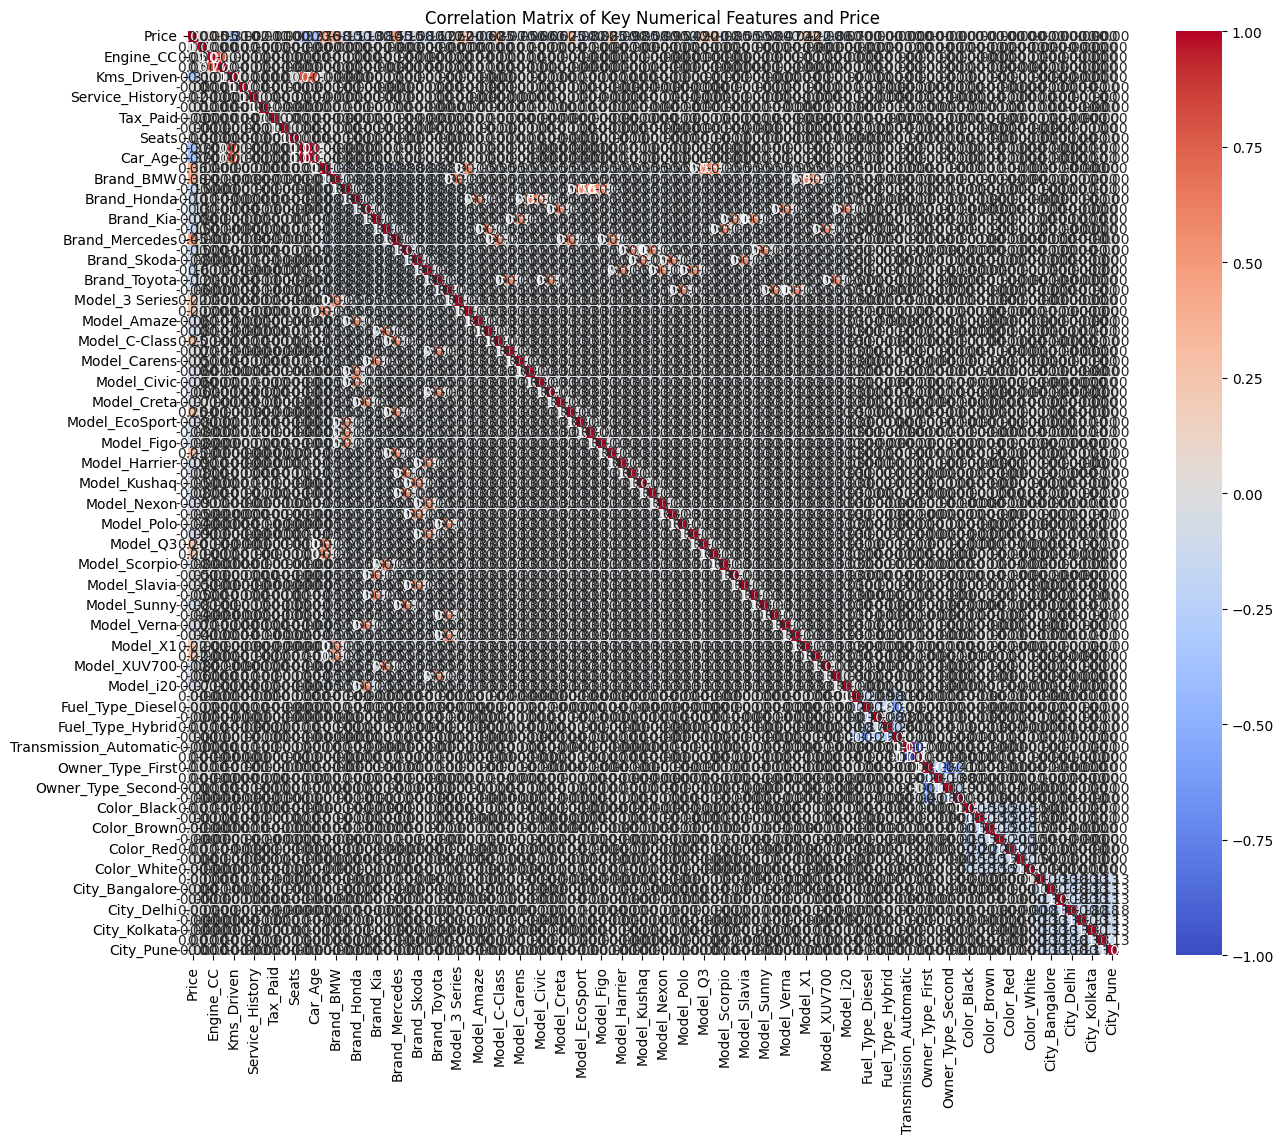

In [ ]:
# Calculate the correlation matrix for the encoded DataFrame
correlation_matrix = df_encoded.corr()

# Display correlations with the target variable 'Price'
print("Top 10 features most positively correlated with Price:")
print(correlation_matrix['Price'].sort_values(ascending=False).head(10))

print("\nTop 10 features most negatively correlated with Price:")
print(correlation_matrix['Price'].sort_values(ascending=True).head(10))

# Visualize the correlation matrix (can be large, so consider a subset or focus on Price)
plt.figure(figsize=(15, 12))
sb.heatmap(correlation_matrix.loc[['Price'] + numerical_cols_for_scaling, ['Price'] + numerical_cols_for_scaling], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Numerical Features and Price')
plt.show()

